# Code Blocks for Generating Images to be used on the Project Posters

03/28/2025 - Gauss and Superposition

In [2]:
from manim import *
import manim_physics as mp
import numpy as np
import random

# Gaussian Sphere

Taken from Dr. Blake's gausslaw.ipynb file and edited to produce an image rather than a video

In [69]:
class GaussSphere(ThreeDScene):
    def construct(self):
        # Set the background color of the scene
        self.camera.background_color = "#Ffffff"  # White

        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)
        axes = ThreeDAxes()  # Add the XYZ coordinate axes

        # Change the color of the axes to black
        axes.set_color(BLACK)

        # Add labels to the axes
        x_label = axes.get_x_axis_label("X").set_color(BLACK)
        y_label = axes.get_y_axis_label("Y").set_color(BLACK)
        z_label = axes.get_z_axis_label("Z").set_color(BLACK)

        # Create the sphere
        sphere = Sphere(radius=1.45, fill_opacity=0.35, color=BLUE_D, stroke_width=1)

        # Create a sphere of charge inside the sphere
        charge = Dot3D(point=ORIGIN, radius=0.1, color=RED)

        # Create the electric field vector arrows around the sphere
        arrows = VGroup()
        directions = [RIGHT, LEFT, UP, DOWN, OUT, IN, UR, UL, DR, DL]
        for dir in directions:
            start_point = sphere.get_center() + dir * sphere.radius
            end_point = start_point + dir *1.5 # Extend the arrow outward
            arrow = Arrow3D(start=start_point, end=end_point, color=RED_D)
            arrows.add(arrow)

        # Add everything to the scene
        self.add(axes, x_label, y_label, z_label,
                 sphere, charge, arrows)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING -s GaussSphere

# Gauss Cube

Taken from Antonio's gaussdraft.py file and edited to produce an image rather than a video

In [70]:
class ChargedGauss(ThreeDScene):
    def construct(self):
        # Set the background color of the scene
        self.camera.background_color = "#Ffffff"  # White
        
        self.set_camera_orientation(phi=75 * DEGREES, theta=-45 * DEGREES)
        axes = ThreeDAxes()  # Add the XYZ coordinate axes

        # Change the color of the axes to black
        axes.set_color(BLACK)

        # Add labels to the axes
        x_label = axes.get_x_axis_label("X").set_color(BLACK)
        y_label = axes.get_y_axis_label("Y").set_color(BLACK)
        z_label = axes.get_z_axis_label("Z").set_color(BLACK)

        # Create the cube
        cube = Cube(side_length=2, fill_opacity=0.35, fill_color=BLUE_E, stroke_width=1)

        # Create a sphere of charge inside the cube
        charge = Dot3D(point=ORIGIN, radius=0.1, color=RED)

        # Create the electric field vector arrows around the cube
        arrows = VGroup()
        directions = [RIGHT, LEFT, UP, DOWN, OUT, IN, UR, UL, DR, DL]
        for dir in directions:
            arrow = Arrow3D(start=cube.get_center() + dir, end=cube.get_center() + dir*2, color=RED_D)
            arrows.add(arrow)

        # Add everything to the scene
        self.add(axes, x_label, y_label, z_label,
                 cube, charge, arrows)


# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING -s ChargedGauss

# Superpostion

Taken from Dr. Blake's superpostion.ipynb file and edited for the poster

The manim module is not an IPython extension.


Manim Community v0.19.0

C:\Users\Antonio\AppData\Local\Temp\ipykernel_15216\4142528246.py:18: DeprecationWarning: This method is not guaranteed to stay around. Please prefer setting the attribute normally or with Mobject.set().
  self.camera.frame.set_width(10)  # Adjust the width as needed for the desired zoom level


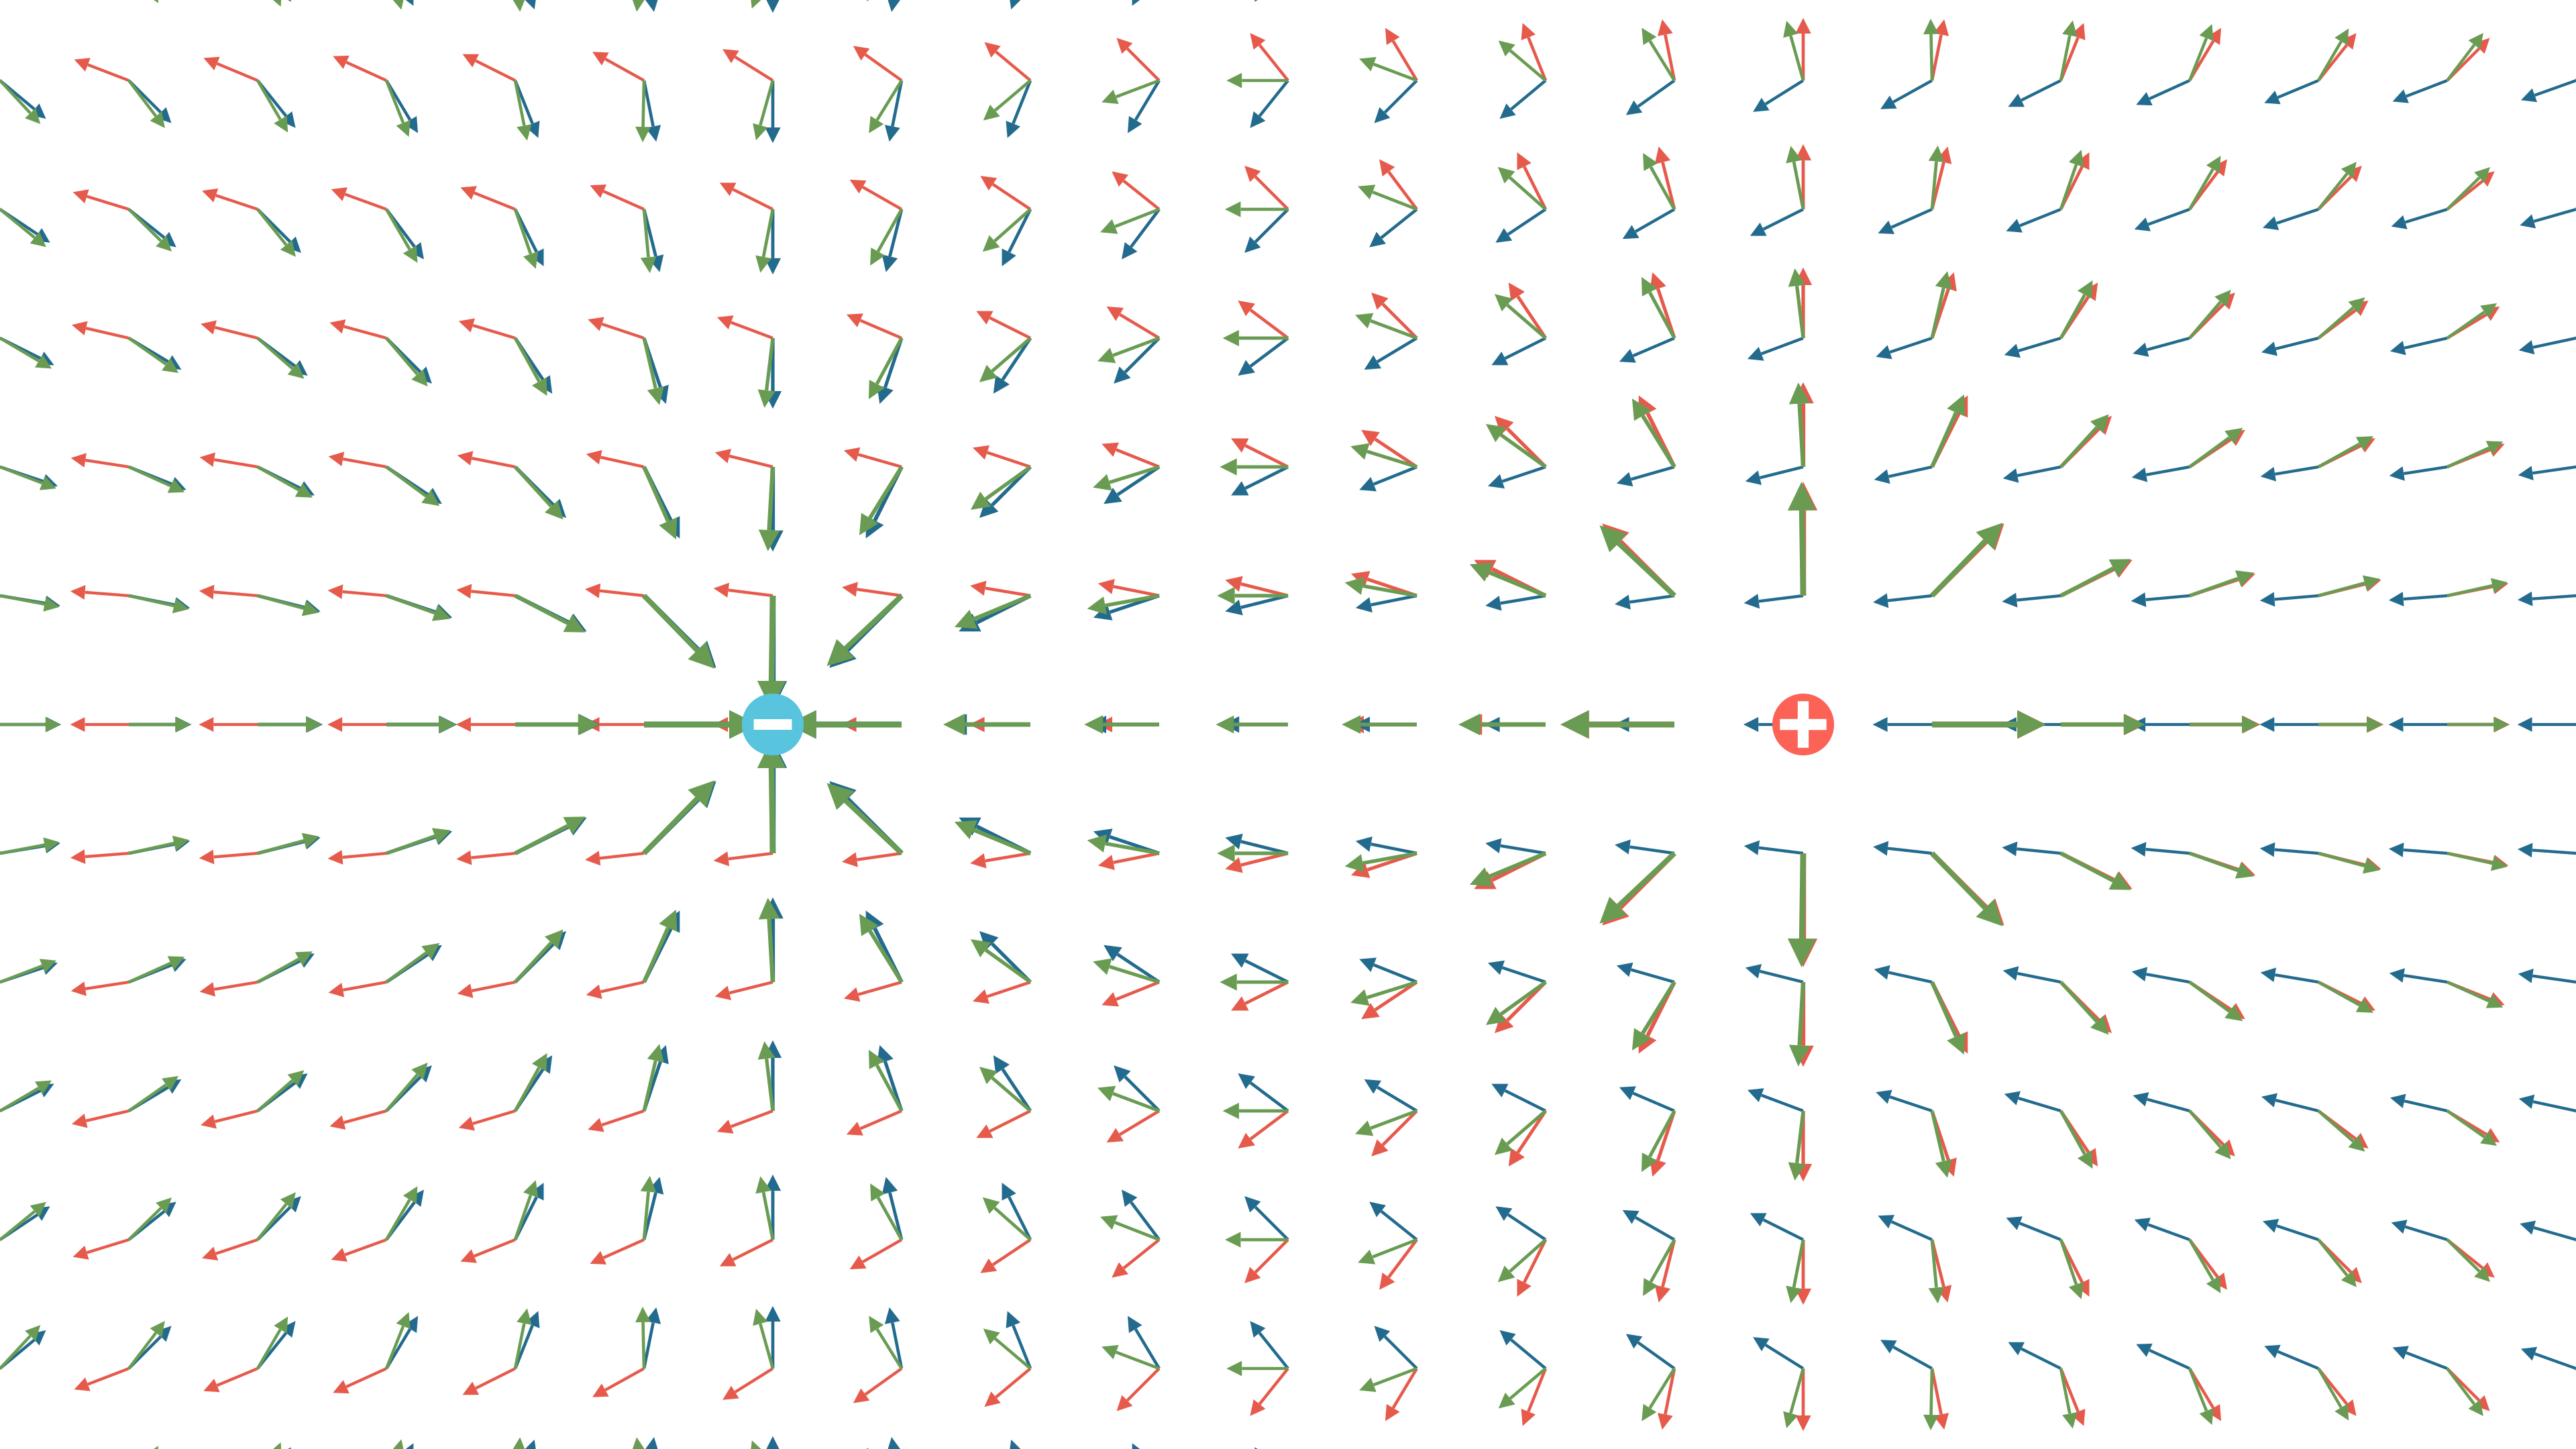

In [2]:
class SuperPosition(ZoomedScene):
    def construct(self):
        # Set the background color of the scene
        self.camera.background_color = "#Ffffff"  # White
        
        charge_1 = mp.Charge(magnitude=1, add_glow=0).move_to(RIGHT*2)
        charge_2 = mp.Charge(magnitude=-1, add_glow=0).move_to(LEFT*2)
        field_1 = mp.ElectricField(charge_1, color=RED_D)
        field_2 = mp.ElectricField(charge_2, color=BLUE_E)
        field_3 = mp.ElectricField(charge_1, charge_2, color=GREEN_E)

        self.add(charge_1, charge_2, field_1, field_2, field_3)
        
        # Center the camera on the origin
        self.camera.frame.move_to(ORIGIN)

        # Zoom into the origin by reducing the frame width
        self.camera.frame.set_width(10)  # Adjust the width as needed for the desired zoom level
        

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING -s SuperPosition

# Vector Addition

Adding a vector addition picture as a zoom into the charges to get the point across

In [74]:
class VectorAddition(Scene):
    def construct(self):
        # Set the background color of the scene
        self.camera.background_color = "#Ffffff"  # White
        
        plane = (
        NumberPlane(x_range=[-3,3,1], y_range=[-15,15,1])
        .add_coordinates()
        .set_color(BLACK)
        )   
        v1 = Vector(2*RIGHT, color=RED)
        v2 = Vector(2*DOWN, color=BLUE)
        self.add(plane)
        self.add(v1, v2)

        # Created the combined vector
        v3 = Vector(v1.get_end() + v2.get_end(), color=GREEN)
        self.add(v3)

# Load the manim extension
%load_ext manim

# Render the main scene
%manim -ql -v WARNING VectorAddition

In [7]:
class electricField(Scene):
    def construct(self):
        r = 1.5  # orbit radius for each charge (opposite sides)
        angle = ValueTracker(0)

        # Create two charges (equal and opposite)
        charge1 = mp.Charge(magnitude=1)
        charge2 = mp.Charge(magnitude=-1)

        # Updaters move the charges as angle changes (they orbit around the origin on opposite sides)
        charge1.add_updater(lambda m: m.move_to(np.array([r * np.cos(angle.get_value()),
                                                          r * np.sin(angle.get_value()), 0])))
        charge2.add_updater(lambda m: m.move_to(np.array([-r * np.cos(angle.get_value()),
                                                          -r * np.sin(angle.get_value()), 0])))

        # Electric field is recreated every frame so it follows the moving charges
        field = always_redraw(lambda: mp.ElectricField(charge1, charge2))

        # Add to scene
        self.add(field, charge1, charge2)

        # Animate the orbit (one full rotation)
        self.play(angle.animate.set_value(2 * PI), run_time=6, rate_func=linear)
        self.wait(0.5)


# Load the manim extension
%load_ext manim

# Render the main scene
%manim -qk -v WARNING electricField

The manim module is not an IPython extension.


Manim Community v0.19.0